In [24]:
import pandas as pd 
df_tracking = pd.read_csv(r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\tracking_all\1.2.3_C1_r50.csv').set_index('frame')
# print(df_tracking)


df_tracking = df_tracking.sort_values(by='frame')
print(df_tracking)
# frame_1_df = df_tracking[df_tracking['frame'] == 1]
# print(frame_1_df)



                name           x           y           w          h  \
frame                                                                 
0          dumbbell0  868.985293  338.531402   50.012598  28.862871   
0            helmet0   38.372909  362.439676   73.974111  52.314549   
0              step0  715.362607  503.275130  206.297278  66.042701   
0       paper towel0   37.943193  361.913207   75.235427  60.015010   
0      spray bottle0   32.350334  359.582803   87.151473  64.869257   
...              ...         ...         ...         ...        ...   
35065   sport drink4  496.000000  309.000000   24.000000  55.000000   
35065        helmet1   48.000000  362.000000   94.000000  60.000000   
35065    flower pot3  160.000000  333.000000   53.000000  59.000000   
35065    jump rope28  514.000000  344.000000   54.000000  22.000000   
35065   granola bar5  469.000000  344.000000   29.000000  21.000000   

       confidence  ground_truth  width  height  
frame                      

In [9]:
#Rescale the coordinates of the label csv to 1280x720 

import pandas as pd
import os 
# Read the CSV file
def change_resolution(file_path):
    df = pd.read_csv(file_path)
    scale_factor = 4/3 #scale factor from 960x540 to 1280x720
    coordinate_columns = ['xmin', 'ymin', 'xmax', 'ymax']
    df[coordinate_columns] = (df[coordinate_columns] * scale_factor).astype(int)

    df['width'] = 1280
    df['height'] = 720
    print(df)
    return df 
# Save the transformed coordinates
# for file in os.listdir(r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\data\ground_truth_labels_copy'):
#     df = change_resolution(os.path.join(r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\data\ground_truth_labels_copy', file))
#     df.to_csv(os.path.join(r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\data\ground_truth_labels_copy', file), index=False)
# # df.to_csv('data/ground_truth_labels/1.2.3_C1_labels.csv', index=False)

               filename  width  height         class  xmin  ymin  xmax  ymax  \
0    1.2.3_C1_00001.png   1280     720        helmet    34   360   112   421   
1    1.2.3_C1_00001.png   1280     720  spray bottle   221   310   253   360   
2    1.2.3_C1_00001.png   1280     720   paper towel   266   285   296   362   
3    1.2.3_C1_00001.png   1280     720          step   721   501   916   576   
4    1.2.3_C1_00001.png   1280     720      dumbbell   869   341   921   368   
..                  ...    ...     ...           ...   ...   ...   ...   ...   
553  1.2.3_C1_00059.png   1280     720   granola bar   469   344   498   365   
554  1.2.3_C1_00059.png   1280     720    flower pot   160   333   213   392   
555  1.2.3_C1_00059.png   1280     720      dumbbell   888   341   938   362   
556  1.2.3_C1_00059.png   1280     720      dumbbell   936   341   992   365   
557  1.2.3_C1_00059.png   1280     720     jump rope   514   344   568   366   

     index  
0        5  
1        5  


In [25]:
import pandas as pd 
import pickle as pkl 

with open(r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\resources\gen_sim_glove_50.pkl', 'rb') as f: 
    glove_vectors = pkl.load(f)
tracking_csv_1 = r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\tracking_all\1.2.3_C1_r50.csv'
tracking_df_1 = pd.read_csv(tracking_csv_1)
print(tracking_df_1)

        frame          name           x           y          w          h  \
0         194   flower pot0   40.234783  362.109711  48.933249  52.833668   
1         195   flower pot0   52.622172  364.008237  47.976467  52.259548   
2         196   flower pot0   57.526331  363.574705  47.186493  51.706933   
3         197   flower pot0   59.975720  364.299649  46.405327  51.415962   
4         198   flower pot0    3.429873  326.859361  45.682774  49.578674   
...       ...           ...         ...         ...        ...        ...   
376124  35061  granola bar5  468.341740  344.925943  31.697070  19.450150   
376125  35062  granola bar5  468.780556  344.806872  31.276563  19.629429   
376126  35063  granola bar5  469.275008  344.631029  30.738902  19.910859   
376127  35064  granola bar5  469.321917  344.673047  29.872956  20.297805   
376128  35065  granola bar5  469.000000  344.000000  29.000000  21.000000   

        confidence  ground_truth  width  height  
0         0.345971       

In [26]:
tracking_df_1 = tracking_df_1.sort_values(by='frame')
tracking_df_1_frame_1 = tracking_df_1[tracking_df_1['frame'] == 0].copy() #will have to iterate over every frame 
#need to put .copy() since i am modifying the copy and not the view 

emb_dim = glove_vectors['apple'].size
tracking_df_1_frame_1.loc[:,'name'] = tracking_df_1_frame_1.loc[:, 'name'].apply(lambda x: "".join([char for char in x if not char.isdigit()]))
print(tracking_df_1_frame_1)


      frame          name           x           y           w          h  \
107       0      dumbbell  868.985293  338.531402   50.012598  28.862871   
1010      0        helmet   38.372909  362.439676   73.974111  52.314549   
709       0          step  715.362607  503.275130  206.297278  66.042701   
1612      0   paper towel   37.943193  361.913207   75.235427  60.015010   
1311      0  spray bottle   32.350334  359.582803   87.151473  64.869257   
408       0      dumbbell  910.926625  339.824578   60.589544  25.958435   

      confidence  ground_truth  width  height  
107     0.997537             1   1280     720  
1010    0.999724             1   1280     720  
709     0.999955             1   1280     720  
1612    0.995214             1   1280     720  
1311    0.876709             1   1280     720  
408     0.999797             1   1280     720  


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import dask.dataframe as dd 

sample_eye = dd.read_csv(r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\eye_all\all_eye_080422.csv").compute()
print(sample_eye)

         frame      video      x      y      sub
0            1  1.2.3.mp4  638.3  360.5  e159001
1            1  1.2.3.mp4  638.0  360.4  e159001
2            1  1.2.3.mp4  637.8  360.4  e159001
3            1  1.2.3.mp4  637.6  360.5  e159001
4            1  1.2.3.mp4  637.1  360.5  e159001
...        ...        ...    ...    ...      ...
1633729  35119  3.1.3.mp4    NaN    NaN  e159100
1633730  35119  3.1.3.mp4    NaN    NaN  e159100
1633731  35119  3.1.3.mp4    NaN    NaN  e159100
1633732  35119  3.1.3.mp4    NaN    NaN  e159100
1633733  35119  3.1.3.mp4  236.0  404.8  e159100

[169559578 rows x 5 columns]


In [17]:
sample_eye_movie_1 = dd.read_csv(r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\eye_all\1.2.3_eye_080422.csv").compute()
print(sample_eye_movie_1)
unique_list = sample_eye_movie_1['frame'].unique().tolist()


         frame      video      x      y      sub
0            1  1.2.3.mp4  638.3  360.5  e159001
1            1  1.2.3.mp4  638.0  360.4  e159001
2            1  1.2.3.mp4  637.8  360.4  e159001
3            1  1.2.3.mp4  637.6  360.5  e159001
4            1  1.2.3.mp4  637.1  360.5  e159001
...        ...        ...    ...    ...      ...
1779087  35129  1.2.3.mp4    NaN    NaN  e159100
1779088  35129  1.2.3.mp4    NaN    NaN  e159100
1779089  35129  1.2.3.mp4    NaN    NaN  e159100
1779090  35129  1.2.3.mp4    NaN    NaN  e159100
1779091  35129  1.2.3.mp4  757.7 -629.3  e159100

[39244395 rows x 5 columns]


In [18]:
def GaussianMask(sizex, sizey, sigma=10, center=None, fix=1):
    """
    Generate a Gaussian mask.
    sizex  : mask width
    sizey  : mask height
    sigma  : Gaussian standard deviation
    center : Gaussian mean (center of the mask)
    fix    : Maximum value of the Gaussian function
    return : Gaussian mask as a 2D numpy array
    """
    x = np.arange(0, sizex, 1, float)
    # print(x)
    y = np.arange(0, sizey, 1, float)
    x, y = np.meshgrid(x, y) #creates a grid of x and y values 
    # print(y.shape)
    # print(y)
    if center is None:
        x0 = sizex // 2
        y0 = sizey // 2
    else:
        if not np.isnan(center[0]) and not np.isnan(center[1]):
            x0 = center[0]
            y0 = center[1]
        else:
            return np.zeros((sizey, sizex))
    gaussian_mask = fix * np.exp(-((x - x0) ** 2 / sigma ** 2 + (y - y0) ** 2 / sigma ** 2)) #2D gaussian filter 
    # print(gaussian_mask.shape)
    # print(gaussian_mask)
    return gaussian_mask


def Fixpos2Densemap(fix_arr, width, height):
    """
    Convert fixation positions to a density map.
    fix_arr : array of fixation data [number of subjects x 3(x,y,fixation)]
    width   : output image width
    height  : output image height
    return  : heatmap as a 2D numpy array
    """
    heatmap = np.zeros((height, width), np.float32)
    for n_subject in range(fix_arr.shape[0]):
        center = (fix_arr[n_subject][1], fix_arr[n_subject][2])
        place = GaussianMask(width, height, sigma=33, center=center)
        # print("Sum: ", np.sum(place))
        heatmap += place
    heatmap /= fix_arr.shape[0] 
    normalized_heatmap = heatmap / heatmap.sum()
 
    return normalized_heatmap*1000 #scale values by 1000 





In [38]:
frame_1 = sample_eye_movie_1[sample_eye_movie_1['frame'] == 50] 
avg_frame = frame_1.groupby(['sub']).mean()
values = avg_frame.to_numpy()
print(values)

width, height = 1280, 720

# Generate the heatmap
heatmap = Fixpos2Densemap(values, width, height)
print(heatmap)

[[  50.          620.85882353  367.47058824]
 [  50.          642.71176471  335.13529412]
 [  50.          496.76470588  346.92352941]
 [  50.          544.64705882  378.57647059]
 [  50.          700.56470588  500.69411765]
 [  50.          496.65882353  342.06470588]
 [  50.          206.02777778  365.87777778]
 [  50.          221.57647059  408.41764706]
 [  50.          892.85555556  350.29444444]
 [  50.          940.7625      407.11875   ]
 [  50.          897.28823529  390.08235294]
 [  50.          494.07647059  314.23529412]
 [  50.          278.95294118  347.51176471]
 [  50.          526.61176471  370.16470588]
 [  50.          921.08823529  389.49411765]
 [  50.          383.98125     525.85625   ]
 [  50.          906.41176471  338.34705882]
 [  50.          815.29411765  460.87058824]
 [  50.          861.48888889  341.77777778]
 [  50.          891.70625     328.45625   ]
 [  50.          416.025       526.1       ]
 [  50.          712.90588235  352.13529412]
 [  50.   

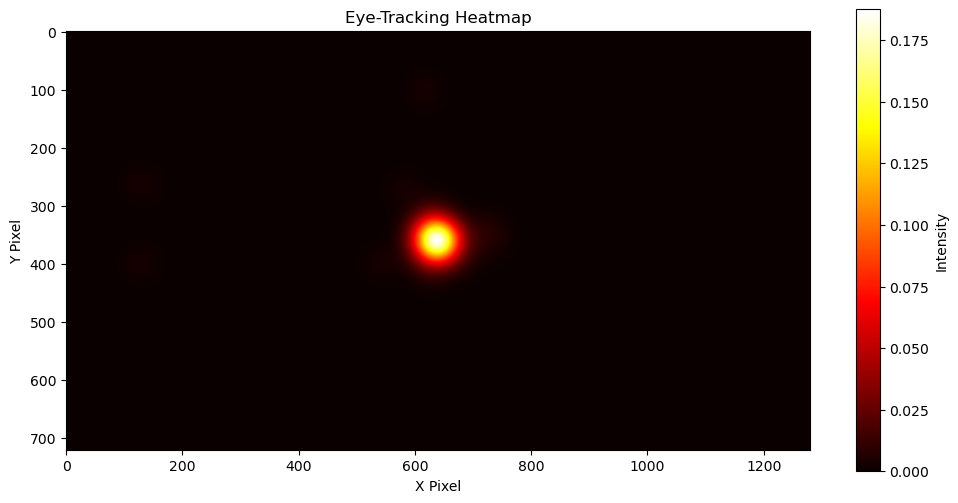

In [32]:
plt.figure(figsize=(12, 6))
plt.imshow(heatmap, cmap='hot')
plt.title('Eye-Tracking Heatmap')
plt.colorbar(label='Intensity')
plt.xlabel('X Pixel')
plt.ylabel('Y Pixel')
plt.show()

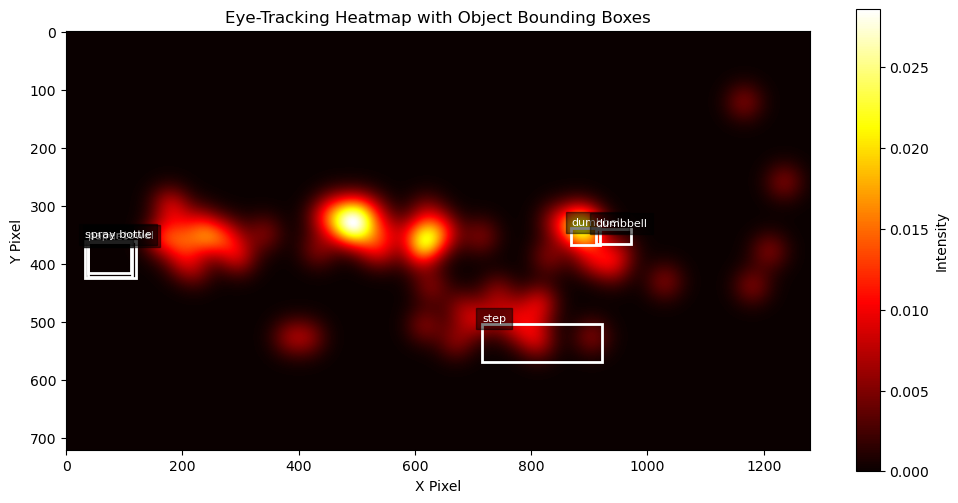

In [39]:

plt.figure(figsize=(12, 6))
plt.imshow(heatmap, cmap='hot')
plt.title('Eye-Tracking Heatmap with Object Bounding Boxes')
plt.colorbar(label='Intensity')


for _, obj in tracking_df_1_frame_1.iterrows():
    rect = plt.Rectangle((obj['x'], obj['y']), 
                        obj['w'],  # width
                        obj['h'],  # height
                        fill=False, edgecolor='white', linewidth=2)
    plt.gca().add_patch(rect)
    # Add object labels
    plt.text(obj['x'], obj['y']-5, obj['name'], 
             color='white', fontsize=8, 
             bbox=dict(facecolor='black', alpha=0.5))

plt.xlabel('X Pixel')
plt.ylabel('Y Pixel')
plt.show()


In [44]:
def attention_weight(heatmap, tracking_df):
    attention_weights = dict()
    for _, obj in tracking_df.iterrows():
        box_values = heatmap[int(obj['y']):int(obj['y'])+int(obj['h']), int(obj['x']):int(obj['x'])+int(obj['w'])]
        attention_weights[obj['name']] = np.mean(box_values)
    print(attention_weights)
    return attention_weights

attention_weights = attention_weight(heatmap, tracking_df_1_frame_1)


{'dumbbell': 0.006445657, 'helmet': 2.6823507e-05, 'step': 0.003385105, 'paper towel': 2.6702379e-05, 'spray bottle': 4.9720988e-05}


In [46]:
import numpy as np

def get_emb(df, emb_dim, attention_weights): 
    average = np.zeros(shape=(1, emb_dim))
    for _, row in df.iterrows():
        r = np.zeros(shape=(1, emb_dim))
        try:
            r += glove_vectors[row['name']]
        except Exception as e:
            # if object not in glove, split into words
            words = row['name'].split(' ')
            for w in words:
                w = w.replace('(', '').replace(')', '')
                r += glove_vectors[w]
            r /= len(words)
        # equal contribution from each object
        average += r * attention_weights[row['name']] #multiply by the attentional weight here
    return average / len(df) 

print(get_emb(tracking_df_1_frame_1, emb_dim, attention_weights))


[[ 1.21836012e-04  4.37185136e-04 -8.64235463e-04 -1.31086848e-03
   8.61045377e-04  9.68890408e-04  3.61561257e-03  8.05851779e-04
   4.03382107e-04  4.96682957e-04 -1.19592652e-03  7.91070625e-04
   1.21279058e-03  2.65445606e-03 -1.48516202e-03 -6.50902551e-04
  -6.42537820e-04  1.06881519e-03  7.03710846e-04 -1.56521647e-03
   7.64854260e-04 -2.01041740e-03 -5.14676599e-04 -4.44944194e-04
  -5.60274560e-04 -1.01148469e-03  6.91166161e-04  2.47671113e-03
  -3.46814916e-05 -2.26617312e-03  1.20378148e-03  2.00096029e-03
  -1.32322345e-03  2.59917943e-03  1.96618000e-05  1.10283004e-03
   1.29588422e-03  1.53823054e-04  1.84930680e-04 -8.05148352e-04
   4.11249988e-04  1.10249845e-04 -1.63342013e-03  8.92218254e-04
  -1.80872786e-03 -7.34281469e-04  2.32910460e-03  1.13213067e-03
   2.76367429e-04 -3.56974373e-04]]


In [47]:
import numpy as np

def get_emb(df, emb_dim): 
    average = np.zeros(shape=(1, emb_dim))
    for _, row in df.iterrows():
        r = np.zeros(shape=(1, emb_dim))
        try:
            r += glove_vectors[row['name']]
        except Exception as e:
            # if object not in glove, split into words
            words = row['name'].split(' ')
            for w in words:
                w = w.replace('(', '').replace(')', '')
                r += glove_vectors[w]
            r /= len(words)
        # equal contribution from each object
        average += r #multiply by the attentional weight here
    return average / len(df) 

print(get_emb(tracking_df_1_frame_1, emb_dim))

[[-0.28382416 -0.0045955  -0.20979783 -0.41331116  0.22721866  0.31037251
   0.45230023 -0.15986167  0.14456342 -0.01298666 -0.06806434  0.255996
   0.18631916  0.55724866 -0.154315    0.08497733 -0.30999834  0.24254417
  -0.15224741 -0.92987334  0.11762732 -0.32735543 -0.076015   -0.43871116
  -0.24445084 -0.82040501 -0.02167391  0.99822464  0.4997175  -0.63639485
   1.10353168  0.38416257 -0.64318584  0.65770668 -0.18776149  0.53953666
   0.46823016  0.20148334  0.28551749 -0.21889548  0.42600917  0.1398975
  -0.35257084  0.36289566 -0.05950033 -0.13435155  0.44144749  0.05992251
   0.24445767 -0.39373166]]


In [6]:
import numpy as np
obj_handling_emb = np.full(shape=(1, 100), fill_value=np.nan)
print(obj_handling_emb)
obj_handling_embs = np.zeros(shape=(0, 100))
print(obj_handling_embs)

obj_handling_embs = np.vstack([obj_handling_embs, obj_handling_emb])
print(obj_handling_embs)



[[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan]]
[]
[[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan]]
